# The z-Distribution <hr style = "border:2.5px solid #0000FF"></hr>

<b> Jehan Jedd Chavez </b>
<br> Comptech Student T09

In [32]:
#import and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from scipy import stats

In [33]:
df=pd.read_csv(r"dataset/transformer-voltage.csv",
                index_col="Sample")

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 1 to 30
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Voltage  30 non-null     float64
dtypes: float64(1)
memory usage: 480.0 bytes


In [35]:
df.describe()

,Voltage
count,30.000000
mean,120.290000
std,1.243285
min,117.000000
25%,119.700000
50%,120.100000
75%,120.500000
max,123.800000


In [36]:
alpha=0.05
z_critical = stats.norm.ppf(1-alpha/2)
z_critical

np.float64(1.959963984540054)

In [37]:
#confidence interval
pop_std = 5
ci_lower, ci_upper = stats.norm.interval(
    confidence = 0.95,
    loc = df['Voltage'].mean(),
    scale= pop_std/np.sqrt(df['Voltage'].count())
)

print(f"CI:[{ci_lower:.2f},{ci_upper:.2f}]")

CI:[118.50,122.08]


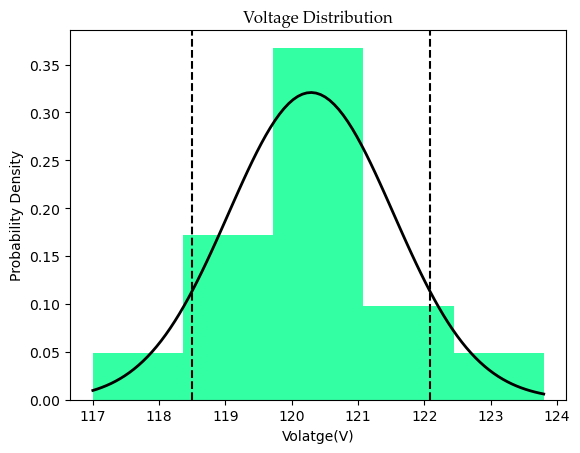

In [ ]:
#Voltage distribution
mean = df['Voltage'].mean()
std = df['Voltage'].std(ddof=1)

#x-axis
x_min = df['Voltage'].min()
x_max = df['Voltage'].max()

#normal distribution plot
x= np.linspace(x_min,x_max,100)
p = stats.norm.pdf(x,mean,std)




plt.plot(x,p,
         color="#000000",
         linewidth=2,
        )

#histogram
plt.hist(df['Voltage'], bins= 5,
         density=True,
         color="#00FF8C",
         alpha=0.8,
        )

plt.title('Voltage Distribution',
          font='Palatino Linotype',
          fontsize=12)
plt.xlabel('Volatge(V)')
plt.ylabel('Probability Density')


#confidence interval
plt.axvline(x=ci_lower,
            color='black',
            linestyle = '--')
plt.axvline(x=ci_upper,
            color='black',
            linestyle = '--')
plt.show()